# **Labeling**

# Load Data

In [3]:
import pandas as pd
df=pd.read_csv(r'../Data/cleaned_data.csv')

In [5]:
data=pd.DataFrame(df['stemming'])
data.head()

,stemming
0,kayak kopi kenang janji_jiwa
1,lanjut janji_jiwa stay hungry tau
2,hari kopi nya caramel macchiato janji_jiwa
3,janji_jiwa seblak aesthetic
4,banyak engga suka janji_jiwa padahal favorit i...


In [7]:
import re

def preprocess_text(text):
    if isinstance(text, str):
        text = re.sub(r'janji jiwa', 'janji_jiwa', text, flags=re.IGNORECASE)
    return text

data['stemming'] = data['stemming'].apply(preprocess_text)


In [9]:
data.head()

,stemming
0,kayak kopi kenang janji_jiwa
1,lanjut janji_jiwa stay hungry tau
2,hari kopi nya caramel macchiato janji_jiwa
3,janji_jiwa seblak aesthetic
4,banyak engga suka janji_jiwa padahal favorit i...


In [11]:
print(data['stemming'].isnull().sum())  

491


In [13]:
dfa=data.dropna(subset=['stemming'])

print(f'Number of rows after removing NaN in the "stemming" column.: {dfa.shape[0]}')

Number of rows after removing NaN in the "stemming" column.: 13734


In [15]:
print(dfa['stemming'].isnull().sum()) 

0


# Inset Lexicon

In [32]:
import pandas as pd

# Load lexicon (positive and negative)
def load_lexicon(file_path):
    lexicon = pd.read_csv(file_path, sep='\t', header=0, names=["word", "weight"])
    lexicon['weight'] = pd.to_numeric(lexicon['weight'], errors='coerce').fillna(0)
    lexicon_dict = dict(zip(lexicon['word'].str.lower(), lexicon['weight']))
    return lexicon_dict

# count sentiment score
def label_sentiment(text, positive_lexicon, negative_lexicon):
    words = text.split()  
    sentiment_score = 0
    word_weights = []  
    
    for word in words:
        word = word.lower()
        if word in positive_lexicon:
            weight = positive_lexicon[word]
        elif word in negative_lexicon:
            weight = negative_lexicon[word]
        else:
            weight = 0
        sentiment_score += weight
        word_weights.append((weight))

    # define label sentiment
    if sentiment_score > 0:
        label = 'positive'
    elif sentiment_score < 0:
        label = 'negative'
    else:
        label = 'neutral'  
    
    return label, sentiment_score, word_weights

positive_lexicon = load_lexicon(r'../Data/positive.tsv')  
negative_lexicon = load_lexicon(r'../Data/negative.tsv')  

df = pd.DataFrame(dfa)

df[['label', 'total_weight', 'word_weights']] = dfa['stemming'].apply(
    lambda x: pd.Series(label_sentiment(x, positive_lexicon, negative_lexicon))
)

In [34]:
df.head(20)

,stemming,label,total_weight,word_weights
0,kayak kopi kenang janji_jiwa,neutral,0,"[-3, 0, 3, 0]"
1,lanjut janji_jiwa stay hungry tau,positive,4,"[2, 0, 0, 0, 2]"
2,hari kopi nya caramel macchiato janji_jiwa,neutral,0,"[0, 0, 0, 0, 0, 0]"
3,janji_jiwa seblak aesthetic,neutral,0,"[0, 0, 0]"
4,banyak engga suka janji_jiwa padahal favorit i...,positive,19,"[3, 0, 3, 0, 0, 5, 0, 0, 0, 3, 0, 0, 0, 5, 0]"
5,halo warga magelang shoes and care open recrui...,neutral,0,"[1, 0, 0, 0, 0, 2, -3, 0]"
6,cari store manager shoe technician kirim cv la...,neutral,0,"[-3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0,..."
7,janji_jiwa,neutral,0,[0]
8,kopi susu sahabat janji_jiwa gila enakkkk bang...,positive,17,"[0, 0, 4, 0, 3, 0, 1, 0, 0, 5, 1, 0, 3, 0]"
9,habis beberes kamar baru sadar nyata tumpuk to...,positive,6,"[3, 0, 0, 0, 2, 4, -4, 0, 0, 3, 1, -3]"


## Count Label

In [37]:
sentiment_counts = df['label'].value_counts()
print(sentiment_counts)

label
positive    8790
neutral     2638
negative    2306
Name: count, dtype: int64


#### Remove Label Neutral
Removing the neutral label to avoid ambiguity in sentiment analysis, ensuring a clearer distinction between positive and negative opinions.

In [40]:
df = df[df['label'] != 'neutral']

In [42]:
# Hitung jumlah sentimen positif dan negatif
sentiment_counts = df['label'].value_counts()

# Tampilkan hasil
print(sentiment_counts)

label
positive    8790
negative    2306
Name: count, dtype: int64


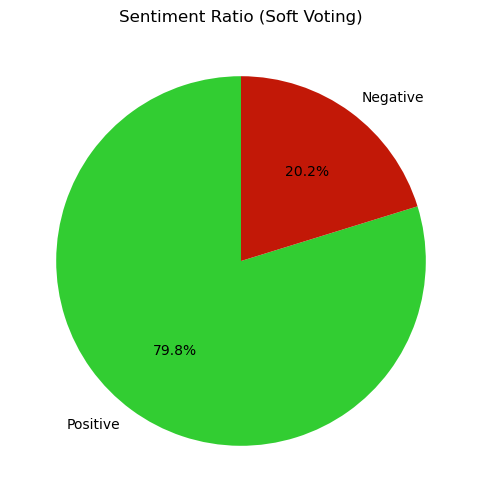

In [44]:
import matplotlib.pyplot as plt

labels = ['Positive', 'Negative']
sizes = [8862, 2246]
colors = ['#32CD32', '#C21807']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Sentiment Ratio (Soft Voting)')
plt.show()


In [45]:
# check NaN value
df = df.dropna(subset=['label'])
print(df['label'].isna().sum())

0


In [46]:
!pip install wordcloud

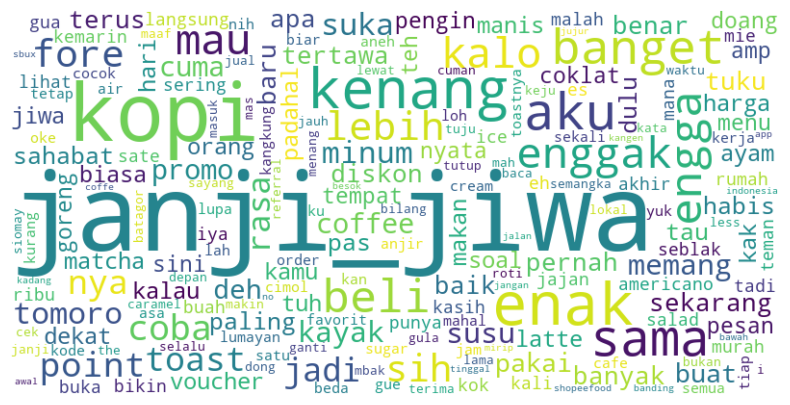

In [54]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Get the default stopwords list from Sastrawi
stopword_factory = StopWordRemoverFactory()
stopwords = stopword_factory.get_stop_words()

positif_words = Counter()

for index, row in df.iterrows():
    sentence = row['stemming']
    label = row['label']
    
    words = word_tokenize(sentence)
    
    words = [word for word in words if word not in stopwords]
    
    if label == 'positive':
        for word in words:
            positif_words[word] += 1  # Tanpa bobot tambahan

wordcloud_positif = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
).generate_from_frequencies(positif_words)

# Plot WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.axis('off')
plt.show()


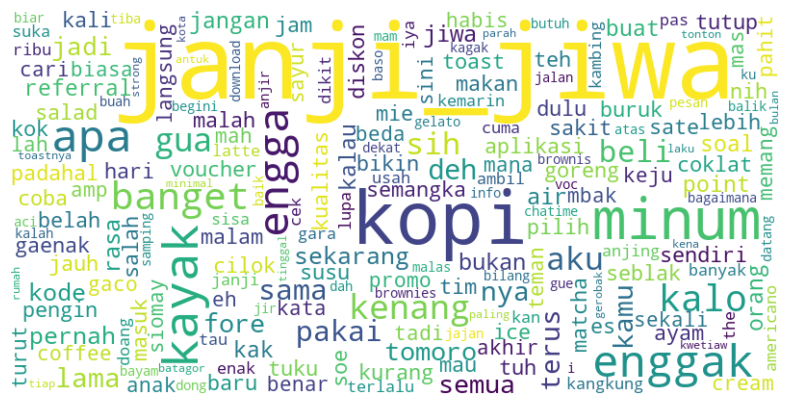

In [56]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Get the default stopwords list from Sastrawi
stopword_factory = StopWordRemoverFactory()
stopwords = stopword_factory.get_stop_words()

positif_words = Counter()

for index, row in df.iterrows():
    sentence = row['stemming']
    label = row['label']
    
    words = word_tokenize(sentence)
    
    words = [word for word in words if word not in stopwords]
    
    if label == 'negative':
        for word in words:
            positif_words[word] += 1  # Tanpa bobot tambahan

wordcloud_positif = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
).generate_from_frequencies(positif_words)

# Plot WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.axis('off')
plt.show()


### Save file 

In [59]:
df = pd.DataFrame(df)
df.to_csv('../Data/data_labeled.csv', index=False)